<a href="https://colab.research.google.com/github/robotlover2/deeplearning26.08.10/blob/main/08.10_DNN_FashionMNIST_%EC%9D%98%EB%A5%98%EB%B6%84%EB%A5%98_TF_Keras_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DNN 실습 프로젝트 (2) (학생용 실습본)
# Fashion MNIST 의류 이미지 분류

---

### 학습 목표

- 앞서 만든 MNIST 모델을 **다른 데이터에 그대로 적용**하고 성능 차이를 설명할 수 있다.
- 데이터가 어려워질수록 **모델 구조와 데이터 증강**이 왜 필요해지는지 근거를 들어 말할 수 있다.
- 혼동행렬을 읽고 **어떤 클래스끼리 헷갈리는지** 찾아낼 수 있다.

### MNIST와 무엇이 다른가

이미지 크기(28×28 흑백)와 클래스 수(10개)는 완전히 같다.
그런데 정확도는 눈에 띄게 떨어진다. **모양이 비슷한 옷들이 섞여 있기 때문**이다.
같은 코드, 다른 데이터에서 성능이 왜 갈리는지 확인하는 것이 이번 실습의 핵심이다.

## 이 노트북 사용법 — 학생용 실습본

이 파일은 **핵심 코드가 빈칸(`____`)으로 비워진 실습본**이다.
수업 중 강사의 설명을 들으며 빈칸을 직접 채워 넣는다.

### 진행 방법

1. 코드 셀 위쪽의 **`채울 곳`** 안내 블록을 먼저 읽는다.
2. 코드 안의 `____` 를 찾아 알맞은 값·함수 이름으로 바꾼다. 각 빈칸에는 `①` `②` 번호가 붙어 있다.
3. `Shift + Enter` 로 셀을 실행한다.

### 실행하면 이런 오류가 난다면

| 오류 메시지 | 원인 |
|---|---|
| `NameError: name '____' is not defined` | 아직 채우지 않은 빈칸이 남아 있다 |
| `SyntaxError` | 빈칸을 지우면서 괄호·따옴표를 함께 지웠다 |

> 빈칸이 아닌 부분은 이미 완성되어 있으니 고치지 않아도 된다.
> 막히면 손을 들거나 채팅으로 알리자. 정답본은 수업 후 배포된다.

## 실행 환경 안내

**Google Colab 기준으로 작성한 노트북이다.**

1. 상단 메뉴 `런타임` → `런타임 유형 변경`
2. 하드웨어 가속기를 `T4 GPU` 로 변경 후 저장
3. 위에서부터 순서대로 셀을 실행한다 (`Shift + Enter`)

> 이 노트북은 CPU에서도 1~2분 내에 학습이 끝난다. GPU는 선택 사항이다.

---
## 1. 라이브러리 및 데이터 로드

In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

tf.random.set_seed(42); np.random.seed(42)

# ┌─ 채울 곳 ─────────────────────────────────────────────────────
# ① Keras에 내장된 의류 이미지 데이터셋 이름
# └───────────────────────────────────────────────────────────────

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()   # ①

CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
CLASS_KO    = ["티셔츠", "바지", "풀오버", "드레스", "코트",
               "샌들", "셔츠", "스니커즈", "가방", "부츠"]

print("학습:", x_train.shape, "/ 테스트:", x_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
학습: (60000, 28, 28) / 테스트: (10000, 28, 28)


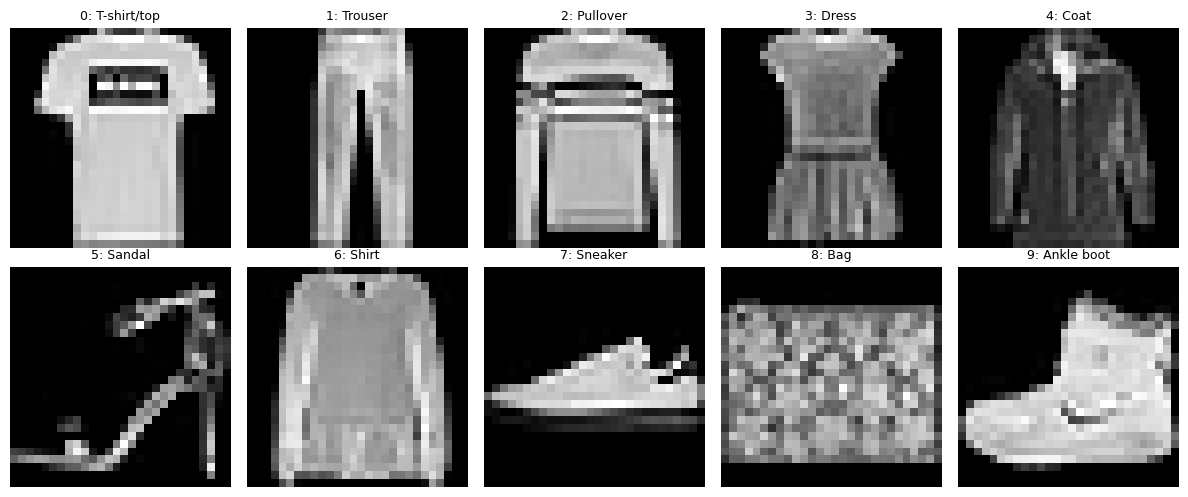

In [3]:
plt.figure(figsize=(12, 5))# 12x5 형태로 이미지 보여줌
for i in range(10):
    idx = np.where(y_train == i)[0][0]
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[idx], cmap="gray")
    plt.title(f"{i}: {CLASS_NAMES[i]}", fontsize=9)
    plt.axis("off")
plt.tight_layout(); plt.show()

> **미리 관찰** : `Pullover(2)` · `Coat(4)` · `Shirt(6)` 세 클래스는 사람 눈으로도 구분이 쉽지 않다.
> 학습이 끝난 뒤 혼동행렬에서 이 세 개가 실제로 얽히는지 확인해 보자.

---
## 2. 전처리

In [4]:
# ┌─ 채울 곳 ─────────────────────────────────────────────────────
# ① 0~1 정규화를 위해 나눌 값 (픽셀 최댓값)
# └───────────────────────────────────────────────────────────────

x_train = x_train.astype("float32") / 255.0   # ①
x_test  = x_test.astype("float32") / 255.0    # ①

x_val, y_val = x_train[:5000], y_train[:5000]
x_train, y_train = x_train[5000:], y_train[5000:]
print(f"train {x_train.shape[0]} / val {x_val.shape[0]} / test {x_test.shape[0]}")

train 55000 / val 5000 / test 10000


---
## 3. 모델 구성 — MNIST와 동일한 구조

**의도적으로 앞 노트북과 같은 구조를 쓴다.** 데이터만 바꿨을 때 성능이 어떻게 달라지는지 보기 위해서다.

In [5]:
# ┌─ 채울 곳 ─────────────────────────────────────────────────────
# ① 은닉층 활성화 함수 (문자열)
# ② 출력층 뉴런 수 : 의류 종류가 10가지
# ③ 출력층 활성화 함수 : 확률 분포로 만든다
# ④ 손실 함수 : 정답이 정수 라벨인 다중 분류용
# └───────────────────────────────────────────────────────────────

def build_dnn(hidden=(128, 64), dropout=0.2):
    layers = [tf.keras.layers.Input(shape=(28, 28)), tf.keras.layers.Flatten()]
    for h in hidden:
        layers.append(tf.keras.layers.Dense(h, activation='relu'))       # ①
        if dropout:
            layers.append(tf.keras.layers.Dropout(dropout))
    layers.append(tf.keras.layers.Dense(10, activation='softmax'))        # ② ③
    return tf.keras.Sequential(layers, name="fashion_dnn")

model = build_dnn()
model.compile(optimizer="adam",
              loss='sparse_categorical_crossentropy',                                              # ④
              metrics=["accuracy"])
model.summary()

Model: "fashion_dnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

---
## 4. 학습

In [6]:
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=20, batch_size=128, verbose=1
)

Epoch 1/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7654 - loss: 0.6673 - val_accuracy: 0.8522 - val_loss: 0.4147
Epoch 2/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8370 - loss: 0.4523 - val_accuracy: 0.8708 - val_loss: 0.3652
Epoch 3/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8530 - loss: 0.4076 - val_accuracy: 0.8738 - val_loss: 0.3401
Epoch 4/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8633 - loss: 0.3781 - val_accuracy: 0.8730 - val_loss: 0.3432
Epoch 5/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8682 - loss: 0.3614 - val_accuracy: 0.8824 - val_loss: 0.3212
Epoch 6/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8727 - loss: 0.3430 - val_accuracy: 0.8778 - val_loss: 0.3294
Epoch 7/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8760 - loss: 0.3339 - val_accuracy: 0.8842 - val_loss: 0.3117
Epoch 8/20
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8819 - loss: 0.3245 - val_accuracy: 

In [7]:
import matplotlib.pyplot as plt

def plot_history(history, title=""):
    """학습 곡선(손실 · 정확도)을 나란히 그린다."""
    h = history.history
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))

    ax[0].plot(h["loss"], label="train")
    if "val_loss" in h:
        ax[0].plot(h["val_loss"], label="validation")
    ax[0].set_title(f"{title} Loss")
    ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Loss"); ax[0].legend(); ax[0].grid(alpha=.3)

    acc_key = "accuracy" if "accuracy" in h else "acc"
    ax[1].plot(h[acc_key], label="train")
    if "val_" + acc_key in h:
        ax[1].plot(h["val_" + acc_key], label="validation")
    ax[1].set_title(f"{title} Accuracy")
    ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Accuracy"); ax[1].legend(); ax[1].grid(alpha=.3)

    plt.tight_layout(); plt.show()

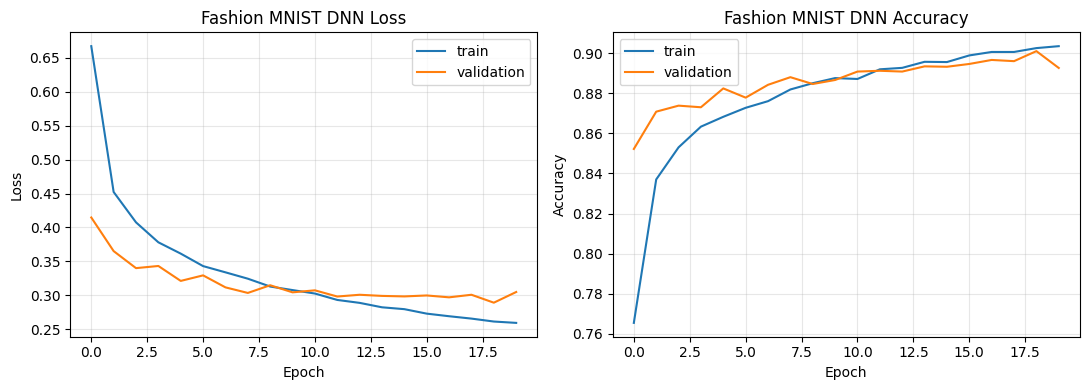

In [8]:
plot_history(history, "Fashion MNIST DNN")

---
## 5. 평가 — MNIST와 비교하기

In [9]:
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Fashion MNIST 테스트 정확도: {acc:.4f}")
print()
print("직전 노트북의 MNIST 정확도와 비교해 보자.")
print("같은 구조 · 같은 이미지 크기인데 왜 차이가 나는가?")

Fashion MNIST 테스트 정확도: 0.8809

직전 노트북의 MNIST 정확도와 비교해 보자.
같은 구조 · 같은 이미지 크기인데 왜 차이가 나는가?


/tmp/ipykernel_834/427013452.py:15: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_834/427013452.py:15: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_834/427013452.py:15: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_834/427013452.py:15: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(byte

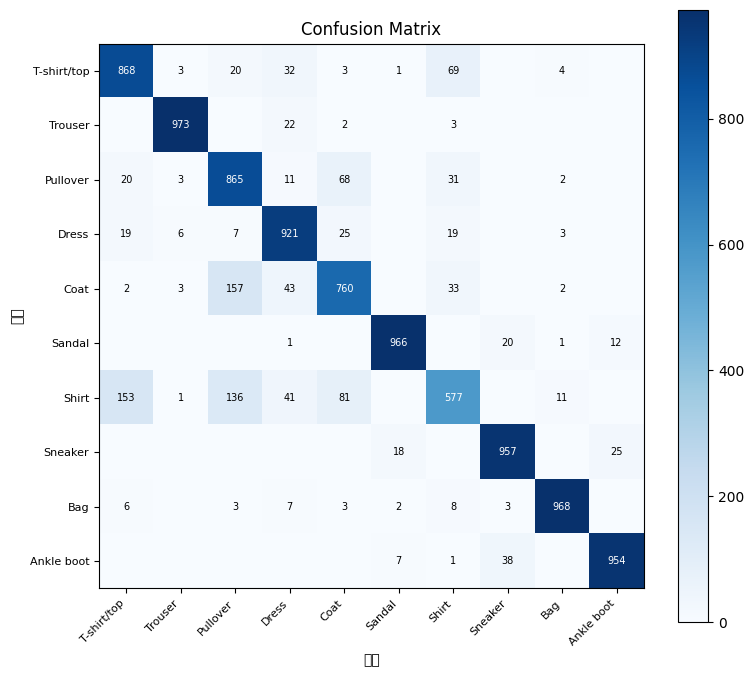

In [10]:
y_prob = model.predict(x_test, verbose=0)
y_pred = y_prob.argmax(axis=1)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 7))
plt.imshow(cm, cmap="Blues"); plt.colorbar()
plt.xticks(range(10), CLASS_NAMES, rotation=45, ha="right", fontsize=8)
plt.yticks(range(10), CLASS_NAMES, fontsize=8)
plt.xlabel("예측"); plt.ylabel("실제"); plt.title("Confusion Matrix")
for i in range(10):
    for j in range(10):
        if cm[i, j] > 0:
            plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=7,
                     color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout(); plt.show()

In [11]:
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=3))

# 가장 많이 헷갈린 조합 5개 찾기
pairs = [(cm[i, j], CLASS_NAMES[i], CLASS_NAMES[j])
         for i in range(10) for j in range(10) if i != j]
pairs.sort(reverse=True)
print("\n[ 가장 많이 혼동한 조합 ]")
for n, t, p in pairs[:5]:
    print(f"  실제 {t:12s} → 예측 {p:12s} : {n}건")

              precision    recall  f1-score   support

 T-shirt/top      0.813     0.868     0.839      1000
     Trouser      0.984     0.973     0.978      1000
    Pullover      0.728     0.865     0.791      1000
       Dress      0.854     0.921     0.886      1000
        Coat      0.807     0.760     0.783      1000
      Sandal      0.972     0.966     0.969      1000
       Shirt      0.779     0.577     0.663      1000
     Sneaker      0.940     0.957     0.948      1000
         Bag      0.977     0.968     0.972      1000
  Ankle boot      0.963     0.954     0.958      1000

    accuracy                          0.881     10000
   macro avg      0.882     0.881     0.879     10000
weighted avg      0.882     0.881     0.879     10000


[ 가장 많이 혼동한 조합 ]
  실제 Coat         → 예측 Pullover     : 157건
  실제 Shirt        → 예측 T-shirt/top  : 153건
  실제 Shirt        → 예측 Pullover     : 136건
  실제 Shirt        → 예측 Coat         : 81건
  실제 T-shirt/top  → 예측 Shirt        : 69건


---
## 6. 오분류 사례 확인

오분류 1191건 / 전체 10000건


/tmp/ipykernel_834/4250930161.py:10: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_834/4250930161.py:10: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_834/4250930161.py:10: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_834/4250930161.py:10: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_fig

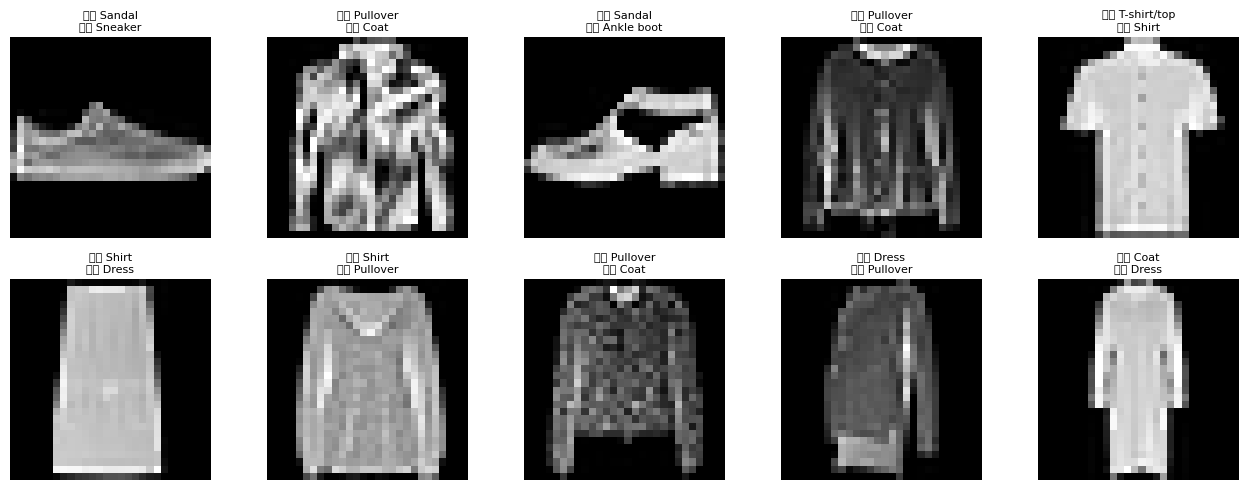

In [12]:
wrong = np.where(y_pred != y_test)[0]
print(f"오분류 {len(wrong)}건 / 전체 {len(y_test)}건")

plt.figure(figsize=(13, 5))
for i, idx in enumerate(wrong[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[idx], cmap="gray")
    plt.title(f"예측 {CLASS_NAMES[y_pred[idx]]}\n정답 {CLASS_NAMES[y_test[idx]]}", fontsize=8)
    plt.axis("off")
plt.tight_layout(); plt.show()

---
## 7. 구조를 바꾸면 얼마나 좋아지는가

은닉층을 키운 모델과 기본 모델을 나란히 학습시켜 비교한다.
**"층을 키우면 무조건 좋아진다"** 는 직관이 맞는지 직접 확인해 보자.

In [14]:
# ┌─ 채울 곳 ─────────────────────────────────────────────────────
# ① 은닉층 하나짜리 작은 모델 : 뉴런 64개 → (64,)  ← 쉼표를 빠뜨리면 튜플이 아니다
# ② 큰 모델 : 512개 → 256개 순서로 두 층
# └───────────────────────────────────────────────────────────────

configs = {
    "small  (64)"      : (64,),          # ①
    "base   (128-64)"  : (128, 64),
    "large  (512-256)" : (512,256),          # ②
}

results = {}
for name, hidden in configs.items():
    m = build_dnn(hidden=hidden)
    m.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    m.fit(x_train, y_train, validation_data=(x_val, y_val),
          epochs=10, batch_size=128, verbose=0)
    _, a = m.evaluate(x_test, y_test, verbose=0)
    results[name] = (m.count_params(), a)
    print(f"{name:18s} 파라미터 {m.count_params():>9,d}  정확도 {a:.4f}")

small  (64)        파라미터    50,890  정확도 0.8708
base   (128-64)    파라미터   109,386  정확도 0.8778
large  (512-256)   파라미터   535,818  정확도 0.8832


/tmp/ipykernel_834/1368839538.py:10: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_834/1368839538.py:10: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_834/1368839538.py:10: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_834/1368839538.py:10: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_834/1368839538.py:10: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_834/1368839538.py:10: UserWarning: Glyph 46384 (\N{HANGUL SYLLABLE DDA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_834/1368839538.py:10: UserWarning: Glyph 47480 (\N{HANGUL S

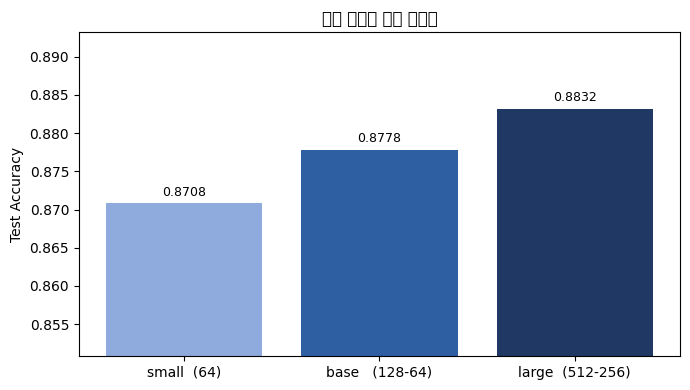

In [15]:
names = list(results.keys())
accs  = [results[n][1] for n in names]

plt.figure(figsize=(7, 4))
bars = plt.bar(names, accs, color=["#8FAADC", "#2E5FA3", "#1F3864"])
plt.ylim(min(accs) - 0.02, max(accs) + 0.01)
plt.ylabel("Test Accuracy"); plt.title("모델 크기에 따른 정확도")
for b, a in zip(bars, accs):
    plt.text(b.get_x() + b.get_width() / 2, a + 0.001, f"{a:.4f}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()

### 관찰

파라미터를 10배 늘려도 정확도는 몇 %p 오르는 데 그친다.
**DNN 구조 자체가 이미지의 공간 정보를 버리고 있기 때문**이다.
28×28 이미지를 784개의 줄로 펴는 순간 "어느 픽셀이 어느 픽셀 옆에 있었는지"가 사라진다.

이 한계를 구조로 해결하는 것이 2일차 **CNN**이다.

---
## 8. 모델 저장 및 정리

In [16]:
model.save("fashion_dnn.keras")
print("저장 완료 : fashion_dnn.keras")

저장 완료 : fashion_dnn.keras


### 1일차 DNN 파트 정리

| 노트북 | 데이터 | 문제 유형 | 출력층 | 손실 함수 |
|---|---|---|---|---|
| 01 | 심장병(표) | 이진 분류 | `Dense(1, sigmoid)` | `binary_crossentropy` |
| 02 | MNIST | 다중 분류 | `Dense(10, softmax)` | `sparse_categorical_crossentropy` |
| 03 | Fashion MNIST | 다중 분류 | `Dense(10, softmax)` | `sparse_categorical_crossentropy` |

데이터와 문제가 바뀌어도 **6단계 절차는 동일**하다.
바뀌는 것은 출력층 형태와 손실 함수뿐이다.

다음 5차시부터는 **모델에 넣기 전 단계**, 즉 이미지 자체를 다루는 방법(OpenCV)을 배운다.